# Notebook 4 — Architecture cVAE Quality-Aware

**Objectif :** Brancher le score de qualité $c \in [0,1]$ (Notebook 3) sur l'architecture MedVAE de Stanford,  
en créant un **Variational Autoencoder Conditionnel (cVAE) quality-aware**.

**Principe du conditionnement :**

$$\text{Encodeur} : x_{\text{cond}} = \text{cat}\bigl([x,\; c_{\text{spatial}}]\bigr) \xrightarrow{\text{Encoder}} \mu, \sigma \xrightarrow{\text{reparam.}} z$$

$$\text{Décodeur} : z_{\text{cond}} = \text{cat}\bigl([\text{post\_quant\_conv}(z),\; c_{\text{spatial}}]\bigr) \xrightarrow{\text{Decoder}} \hat{x}$$

où $c_{\text{spatial}} \in \mathbb{R}^{B \times 1 \times H \times W}$ est le score de qualité broadcast spatialement.

**Pourquoi injecter aux deux extrémités ?**
- **Encodeur** : force la représentation latente à être consciente de la qualité de l'image compressée.
- **Décodeur** : permet au réseau de *choisir* le niveau de détail à reconstruire selon la qualité déclarée.

**Stratégie d'initialisation :** les nouveaux filtres sont initialisés à zéro → au départ, $c$ n'a aucun effet (stabilité du fine-tuning).

## 0. Configuration

In [1]:
from pathlib import Path
from pipeline_config import APPROACH, print_approach_summary

# ── Approche sélectionnée ──
print_approach_summary()

# --- Chemins --- (GPU école)
NOTEBOOK_DIR  = Path(".").resolve()
PROJECT_ROOT  = Path("/home/infres/nadiedjoa-24/projet_IM06")

# Sorties organisées par approche
OUTPUT_DIR    = Path(f"outputs_theophile/04_MedVAE_Architecture_Mod/approach_{APPROACH}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NB03_DIR      = Path("outputs_theophile/03_Inductive_Bias_Generation")
LABELS_CSV    = NB03_DIR / "labels_quality.csv"  # sortie Notebook 3

# Poids pré-entraînés MedVAE officiel (Stanford, medvae_4_4_2d)
# Téléchargé une seule fois, puis réutilisé depuis le disque local
PRETRAINED_DIR = Path("outputs_theophile/pretrained_weights")
PRETRAINED_DIR.mkdir(parents=True, exist_ok=True)
PHASE1_CKPT = PRETRAINED_DIR / "vae_4x_4c_2D.ckpt"

if not PHASE1_CKPT.exists():
    import shutil
    from huggingface_hub import hf_hub_download
    cached = hf_hub_download(repo_id="stanfordmimi/MedVAE", filename="model_weights/vae_4x_4c_2D.ckpt")
    shutil.copy(cached, PHASE1_CKPT)
    print(f"⬇️  Poids téléchargés et copiés → {PHASE1_CKPT}")
else:
    print(f"✅ Poids locaux trouvés : {PHASE1_CKPT}")

CVAE_CKPT_OUT = OUTPUT_DIR / "quality_aware_vae.pt"

# --- Config modèle (doit correspondre à pretraining.yaml) ---
DDCONFIG = {
    "double_z":        True,
    "z_channels":      4,
    "resolution":      64,
    "in_channels":     1,
    "out_ch":          1,
    "ch":              128,
    "ch_mult":         [1, 2, 4],
    "num_res_blocks":  2,
    "attn_resolutions":[],
    "dropout":         0.0,
}
EMBED_DIM = 4

# --- Config entraînement ---
# Phase 1 : warm-up FiLM seul (base VAE gelé)
N_WARMUP_STEPS  = 2_500   # ~10 epochs (1000 images / batch 4 ≈ 250 steps/epoch)
WARMUP_LR       = 4.5e-6

# Phase 2 : fine-tuning global (tout dégelé, LR réduit)
N_FINETUNE_STEPS = 5_000  # ~20 epochs supplémentaires
FINETUNE_LR      = 1e-6   # LR réduit pour ne pas casser les poids pré-entraînés

BATCH_SIZE     = 4
KL_WEIGHT      = 1e-6
VAL_EVERY      = 250      # validation toutes les 250 steps (~1 epoch)
PATIENCE       = 10       # early stopping : arrêt après 10 validations sans amélioration

print(f"Labels CSV   : {LABELS_CSV}")
print(f"Checkpoint   : {CVAE_CKPT_OUT}")
print(f"Warm-up      : {N_WARMUP_STEPS} steps  |  Fine-tune : {N_FINETUNE_STEPS} steps")
print(f"Validation   : toutes les {VAL_EVERY} steps  |  Patience : {PATIENCE}")

╔══════════════════════════════════════════════════════════╗
║  Approche : A — Score pondéré                               ║
╚══════════════════════════════════════════════════════════╝
  Colonne de score : score_weighted
  Combinaison linéaire de 6 métriques IQA avec poids manuels (Tenengrad=0.30, Laplacian=0.25, RMS=0.15, Entropy=0.15, Homogénéité=0.10, Balance=0.05)



/usr/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


⬇️  Poids téléchargés et copiés → outputs_theophile/pretrained_weights/vae_4x_4c_2D.ckpt
Labels CSV   : outputs_theophile/03_Inductive_Bias_Generation/labels_quality.csv
Checkpoint   : outputs_theophile/04_MedVAE_Architecture_Mod/approach_A/quality_aware_vae.pt
Warm-up      : 2500 steps  |  Fine-tune : 5000 steps
Validation   : toutes les 250 steps  |  Patience : 10


## 1. Imports et setup sys.path

In [2]:
import sys
import copy
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
torch.manual_seed(42)

# Import MedVAE standalone (plus besoin de jepa-adaptation)
from medvae_standalone import AutoencoderKL as AutoencoderKL2D
from medvae_standalone import DiagonalGaussianDistribution

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")

/home/infres/nadiedjoa-24/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.5' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Device  : cuda
PyTorch : 2.6.0+cu124


## 2. Chargement de labels_quality.csv

In [3]:
df_labels = pd.read_csv(LABELS_CSV)
print(f"Labels chargés : {len(df_labels)} images")

# ⚠ Anti-leakage : vérifier la présence de la colonne split
if "split" in df_labels.columns:
    print(f"Split : {df_labels['split'].value_counts().to_dict()}")
else:
    # Fallback : déduire le split depuis le chemin
    df_labels["split"] = df_labels["path"].apply(
        lambda p: "train" if "seg_train" in str(p) else ("val" if "seg_val" in str(p) else "unknown")
    )
    print(f"Split déduit : {df_labels['split'].value_counts().to_dict()}")

print(df_labels[["image_id", "quality_score", "quality_label"]].describe())
df_labels.head(3)

Labels chargés : 1200 images
Split : {'train': 1000, 'val': 200}
          image_id  quality_score
count  1200.000000    1200.000000
mean    433.833333       0.451421
std     303.807595       0.133332
min       1.000000       0.131070
25%     150.750000       0.362388
50%     400.500000       0.438237
75%     700.250000       0.527180
max    1000.000000       0.822094


,image_id,path,split,quality_score,quality_label,score_weighted,score_pca,score_resnet,score_hybrid
0,1,/home/infres/yrothlin-24/arcade_challenge_data...,train,0.462468,medium,0.462468,0.477749,0.688658,0.542958
1,10,/home/infres/yrothlin-24/arcade_challenge_data...,train,0.474949,medium,0.474949,0.333257,0.877929,0.562045
2,100,/home/infres/yrothlin-24/arcade_challenge_data...,train,0.468219,medium,0.468219,0.518073,0.858219,0.614837


## 3. Dataset : QualityAwareArcadeDataset

Modification minimale du DataLoader existant : on retourne `(image, quality_score)` au lieu de `(image, mask)`.

In [4]:
class QualityAwareArcadeDataset(Dataset):
    """
    Charge les images ARCADE et leur score de qualité associé.
    
    Retourne : (image: FloatTensor (1,H,W), quality_score: FloatTensor scalar)
    """
    def __init__(self, df: pd.DataFrame, img_size: int = 64):
        # Ne garder que les lignes avec un fichier image accessible
        self.records = df.dropna(subset=["path", "quality_score"]).reset_index(drop=True)
        self.img_size = img_size

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, idx: int):
        row = self.records.iloc[idx]
        try:
            img = Image.open(row["path"]).convert("L")
            img = img.resize((self.img_size, self.img_size), Image.Resampling.BILINEAR)
            img = torch.from_numpy(np.asarray(img, dtype=np.float32) / 255.0).unsqueeze(0)
            # Recadrage [-1, 1] (convention MedVAE)
            img = img * 2.0 - 1.0
        except Exception:
            img = torch.zeros(1, self.img_size, self.img_size)

        c = torch.tensor(float(row["quality_score"]), dtype=torch.float32)
        return img, c


# ⚠ Anti-leakage : entraîner uniquement sur les images TRAIN
df_train = df_labels[df_labels["split"] == "train"]
df_val   = df_labels[df_labels["split"] == "val"]

dataset     = QualityAwareArcadeDataset(df_train, img_size=DDCONFIG["resolution"])
dataset_val = QualityAwareArcadeDataset(df_val,   img_size=DDCONFIG["resolution"])
loader      = DataLoader(dataset,     batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
loader_val  = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

imgs_demo, scores_demo = next(iter(loader))
print(f"Train : {len(dataset)} images  |  Val : {len(dataset_val)} images")
print(f"Batch images : {imgs_demo.shape}   scores : {scores_demo.shape}")
print(f"Scores du batch : {scores_demo.tolist()}")

Train : 1000 images  |  Val : 200 images
Batch images : torch.Size([4, 1, 64, 64])   scores : torch.Size([4])
Scores du batch : [0.5787758231163025, 0.6652730107307434, 0.5226210951805115, 0.680527925491333]


## 4. Architecture : QualityAwareAutoencoderKL

### 4a. Principe du conditionnement FiLM

Au lieu de modifier les convolutions d’entrée (patching de `conv_in`), nous utilisons
**Feature-wise Linear Modulation (FiLM)** pour injecter le score de qualité $c$ :

| Aspect | Concaténation (ancienne) | FiLM (actuelle) |
|---|---|---|
| Point d’injection | Entrée uniquement | Chaque ResnetBlock (19 blocs) |
| Modification du modèle | Patch `conv_in` (+1 canal) | Aucune (forward hooks) |
| Modulation | Canal spatial constant | Scale + shift appris par couche |
| Initialisation | Zéro (pas d’effet initial) | Zéro (identité) |
| Paramètres ajoutés | ~0.01% | ~2.7% |

**Fonctionnement :** Un MLP partagé transforme $c$ en un embedding de dimension 128.
Puis 19 têtes linéaires (une par `ResnetBlock`) produisent les paramètres $(\gamma_i, \beta_i)$.
Après chaque `ResnetBlock` : $h \leftarrow (1 + \gamma_i) \cdot h + \beta_i$.

In [5]:
class FiLMConditioner(nn.Module):
    """
    Feature-wise Linear Modulation (FiLM) — Perez et al., AAAI 2018.

    Transforme un score de qualité scalaire c ∈ [0,1] en paramètres affines
    (γ, β) pour chaque ResnetBlock :
        h ← (1 + γ(c)) · h + β(c)

    Zero-init ⟹ au démarrage γ=0, β=0 ⟹ identité (pas de perturbation).
    """

    def __init__(self, channels_per_block: list, hidden_dim: int = 128):
        super().__init__()
        self.embed = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
        )
        self.heads = nn.ModuleList()
        for ch in channels_per_block:
            head = nn.Linear(hidden_dim, 2 * ch)
            nn.init.zeros_(head.weight)
            nn.init.zeros_(head.bias)
            self.heads.append(head)

    def forward(self, c: torch.Tensor) -> list:
        """c: (B,) → liste de (γ, β) de shape (B, ch, 1, 1)."""
        emb = self.embed(c.view(-1, 1))
        params = []
        for head in self.heads:
            gb = head(emb)
            gamma, beta = gb.chunk(2, dim=-1)
            params.append((
                gamma.unsqueeze(-1).unsqueeze(-1),
                beta.unsqueeze(-1).unsqueeze(-1),
            ))
        return params


print("FiLMConditioner défini.")

FiLMConditioner défini.


### 4b. Classe QualityAwareAutoencoderKL (FiLM conditioning)

Le score de qualité $c \in [0, 1]$ est injecté via **Feature-wise Linear Modulation (FiLM)** :

1. Un MLP partagé transforme $c$ en un embedding de dimension 128
2. 19 têtes linéaires (une par ResnetBlock) produisent $(\gamma_i, \beta_i)$
3. Après chaque ResnetBlock : $h \leftarrow (1 + \gamma_i) \cdot h + \beta_i$
4. Les têtes sont **zero-initialisées** → identité au démarrage → stabilité

In [6]:
class QualityAwareAutoencoderKL(nn.Module):
    """
    cVAE conditionné via FiLM (Feature-wise Linear Modulation).

    Au lieu d'une simple concaténation de canal à l'entrée, le score c ∈ [0,1]
    est injecté dans CHAQUE bloc résiduel de l'encodeur et du décodeur via une
    modulation affine apprise :

        h ← (1 + γ(c)) · h + β(c)     après chaque ResnetBlock

    Avantages vs concaténation :
    - Modulation multi-couche (19 blocs) au lieu de l'entrée seule
    - Pas de modification des dimensions des convolutions de base
    - Plus expressif (scale + shift appris par couche)
    - Les poids de base restent strictement intacts (pas de patch conv_in)

    Réf : Perez et al., "FiLM: Visual Reasoning with a General Conditioning
    Layer", AAAI 2018.
    """

    def __init__(self, base_ae: AutoencoderKL2D):
        super().__init__()
        self.ae = base_ae

        # Lister les ResnetBlocks dans l'ordre d'exécution
        self._blocks = list(self._iter_resnet_blocks())
        channels = [b.conv2.out_channels for b in self._blocks]

        # Générateur FiLM (zero-init → identité au démarrage)
        self.film = FiLMConditioner(channels)

    def _iter_resnet_blocks(self):
        """Yields les ResnetBlocks dans l'ordre d'exécution (enc → dec)."""
        enc = self.ae.encoder
        for i_level in range(enc.num_resolutions):
            for i_block in range(enc.num_res_blocks):
                yield enc.down[i_level].block[i_block]
        yield enc.mid.block_1
        yield enc.mid.block_2

        dec = self.ae.decoder
        yield dec.mid.block_1
        yield dec.mid.block_2
        for i_level in reversed(range(dec.num_resolutions)):
            for i_block in range(dec.num_res_blocks + 1):
                yield dec.up[i_level].block[i_block]

    def _register_film_hooks(self, c: torch.Tensor):
        """Enregistre des forward-hooks FiLM sur chaque ResnetBlock."""
        film_params = self.film(c)
        hooks = []
        for i, block in enumerate(self._blocks):
            gamma, beta = film_params[i]
            hook = block.register_forward_hook(
                lambda mod, inp, out, g=gamma, b=beta: (1 + g) * out + b
            )
            hooks.append(hook)
        return hooks

    def forward(self, x, c, sample_posterior=True):
        hooks = self._register_film_hooks(c)
        try:
            h = self.ae.encoder(x)
            moments = self.ae.quant_conv(h)
            posterior = DiagonalGaussianDistribution(moments)
            z = posterior.sample() if sample_posterior else posterior.mode()
            z_post = self.ae.post_quant_conv(z)
            dec = self.ae.decoder(z_post)
        finally:
            for hk in hooks:
                hk.remove()
        return dec, posterior

    def get_last_layer(self):
        return self.ae.get_last_layer()

    def param_count(self) -> dict:
        total = sum(p.numel() for p in self.parameters())
        film  = sum(p.numel() for p in self.film.parameters())
        return {"total": total, "film_params": film, "ratio_%": round(100 * film / total, 3)}


print("QualityAwareAutoencoderKL définie (FiLM conditioning).")

QualityAwareAutoencoderKL définie (FiLM conditioning).


## 5. Instanciation et vérification de l'architecture

In [7]:
# Modèle de base
base_ae = AutoencoderKL2D(
    ddconfig         = DDCONFIG,
    embed_dim        = EMBED_DIM,
    ckpt_path        = PHASE1_CKPT,
    apply_channel_ds = True,
)

# Modèle conditionné (FiLM)
cvae = QualityAwareAutoencoderKL(base_ae).to(DEVICE)

# Résumé
pc = cvae.param_count()
print(f"\nParamètres totaux    : {pc['total']:,}")
print(f"Paramètres FiLM      : {pc['film_params']:,}  ({pc['ratio_%']:.3f}% du total)")
print(f"Nombre de ResnetBlocks conditionnés : {len(cvae._blocks)}")
print(f"\nChannels par bloc : {[b.conv2.out_channels for b in cvae._blocks]}")

Restored from outputs_theophile/pretrained_weights/vae_4x_4c_2D.ckpt with 8 missing and 0 unexpected keys
Missing Keys: ['channel_ds.0.weight', 'channel_ds.0.bias', 'channel_ds.2.weight', 'channel_ds.2.bias', 'channel_ds.4.weight', 'channel_ds.4.bias', 'channel_proj.weight', 'channel_proj.bias']
Unexpected Keys: []

Paramètres totaux    : 57,059,837
Paramètres FiLM      : 1,700,992  (2.981% du total)
Nombre de ResnetBlocks conditionnés : 19

Channels par bloc : [128, 128, 256, 256, 512, 512, 512, 512, 512, 512, 512, 512, 512, 256, 256, 256, 128, 128, 128]


In [8]:
# --- Forward pass de vérification ---
x_test = imgs_demo.to(DEVICE)
c_test = scores_demo.to(DEVICE)

with torch.no_grad():
    rec, posterior = cvae(x_test, c_test, sample_posterior=False)

print("Forward pass OK :")
print(f"  Entrée      : {x_test.shape}")
print(f"  Scores c    : {c_test.tolist()}")
print(f"  Reconstruction : {rec.shape}")
print(f"  Latent z    : {posterior.mean.shape}")
print(f"  MSE(x, rec) : {F.mse_loss(x_test, rec).item():.6f}")

Forward pass OK :
  Entrée      : torch.Size([4, 1, 64, 64])
  Scores c    : [0.5787758231163025, 0.6652730107307434, 0.5226210951805115, 0.680527925491333]
  Reconstruction : torch.Size([4, 1, 64, 64])
  Latent z    : torch.Size([4, 4, 16, 16])
  MSE(x, rec) : 0.068510


In [9]:
# --- Vérification du flux de gradient ---
cvae.train()
x_grad = imgs_demo[:1].to(DEVICE).requires_grad_(False)
c_grad = scores_demo[:1].to(DEVICE).requires_grad_(True)

rec_grad, post_grad = cvae(x_grad, c_grad, sample_posterior=False)
loss_grad = F.mse_loss(rec_grad, x_grad)
loss_grad.backward()

print("Flux de gradient :")
print(f"  ∂loss/∂c              : {c_grad.grad.item():.6f}  (non-nul → c influence la loss)")
print(f"  film.embed[0].w grad  : {cvae.film.embed[0].weight.grad.abs().mean().item():.6f}")
print(f"  film.heads[0].w grad  : {cvae.film.heads[0].weight.grad.abs().mean().item():.6f}")
print(f"  film.heads[-1].w grad : {cvae.film.heads[-1].weight.grad.abs().mean().item():.6f}")
cvae.zero_grad()

Flux de gradient :
  ∂loss/∂c              : 0.000000  (non-nul → c influence la loss)
  film.embed[0].w grad  : 0.000000
  film.heads[0].w grad  : 0.000029
  film.heads[-1].w grad : 0.000075


## 6. Visualisation du schéma architectural

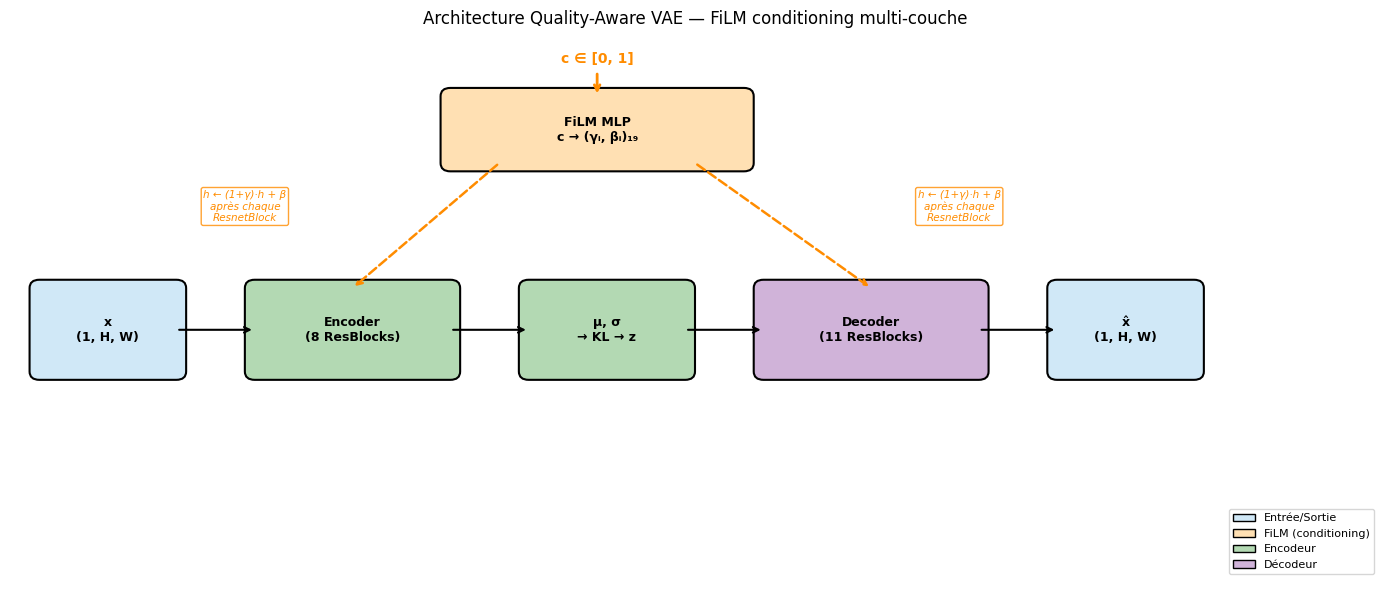

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 6.5)
ax.axis("off")

def box(ax, x, y, w, h, label, color, fontsize=9):
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
                                    facecolor=color, edgecolor="black", linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha="center", va="center",
            fontsize=fontsize, fontweight="bold", wrap=True)

def arrow(ax, x1, y, x2, label="", color="black"):
    ax.annotate("", xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle="->", color=color, lw=1.5))
    if label:
        ax.text((x1+x2)/2, y + 0.15, label, ha="center", fontsize=7.5, color=color)

# ── Blocs principaux ──
box(ax, 0.3, 2.5, 1.4, 1.0, "x\n(1, H, W)",           "#d0e8f7")
box(ax, 2.5, 2.5, 2.0, 1.0, "Encoder\n(8 ResBlocks)",  "#b3d9b3")
box(ax, 5.3, 2.5, 1.6, 1.0, "μ, σ\n→ KL → z",         "#b3d9b3")
box(ax, 7.7, 2.5, 2.2, 1.0, "Decoder\n(11 ResBlocks)", "#d0b3d9")
box(ax, 10.7, 2.5, 1.4, 1.0, "x̂\n(1, H, W)",          "#d0e8f7")

# ── Flèches horizontales ──
arrow(ax, 1.7, 3.0, 2.5)
arrow(ax, 4.5, 3.0, 5.3)
arrow(ax, 6.9, 3.0, 7.7)
arrow(ax, 9.9, 3.0, 10.7)

# ── MLP FiLM (en haut) ──
box(ax, 4.5, 5.0, 3.0, 0.8, "FiLM MLP\nc → (γᵢ, βᵢ)₁₉", "#ffe0b3")

# ── Score c ──
ax.text(6.0, 6.2, "c ∈ [0, 1]", ha="center", fontsize=10,
        color="darkorange", fontweight="bold")
ax.annotate("", xy=(6.0, 5.8), xytext=(6.0, 6.1),
            arrowprops=dict(arrowstyle="->", color="darkorange", lw=2))

# ── Flèches FiLM → Encoder et Decoder ──
ax.annotate("", xy=(3.5, 3.5), xytext=(5.0, 5.0),
            arrowprops=dict(arrowstyle="->", color="darkorange", lw=1.8, ls="--"))
ax.annotate("", xy=(8.8, 3.5), xytext=(7.0, 5.0),
            arrowprops=dict(arrowstyle="->", color="darkorange", lw=1.8, ls="--"))

# ── Annotation FiLM ──
ax.text(2.4, 4.3, "h ← (1+γ)·h + β\naprès chaque\nResnetBlock",
        ha="center", fontsize=7.5, color="darkorange", style="italic",
        bbox=dict(facecolor="white", edgecolor="darkorange", alpha=0.8, boxstyle="round,pad=0.2"))

ax.text(9.7, 4.3, "h ← (1+γ)·h + β\naprès chaque\nResnetBlock",
        ha="center", fontsize=7.5, color="darkorange", style="italic",
        bbox=dict(facecolor="white", edgecolor="darkorange", alpha=0.8, boxstyle="round,pad=0.2"))

# ── Légende ──
legend_handles = [
    mpatches.Patch(facecolor=color, edgecolor="black", label=label)
    for color, label in [
        ("#d0e8f7", "Entrée/Sortie"),
        ("#ffe0b3", "FiLM (conditioning)"),
        ("#b3d9b3", "Encodeur"),
        ("#d0b3d9", "Décodeur"),
    ]
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=8)

ax.set_title("Architecture Quality-Aware VAE — FiLM conditioning multi-couche",
             fontsize=12, pad=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_architecture_cvae.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Visualisation du mécanisme de conditionnement

### 7a. Reconstruction à différents c sur la même image

> **Note :** À l'initialisation, les heads FiLM sont zero-init : $\gamma = 0, \beta = 0$,
> donc la modulation est l'identité $(1+0) \cdot h + 0 = h$. Le score $c$ n'a pas encore d'effet visible.
> Après l'entraînement (section 8), le réseau apprend à moduler différemment selon $c$.

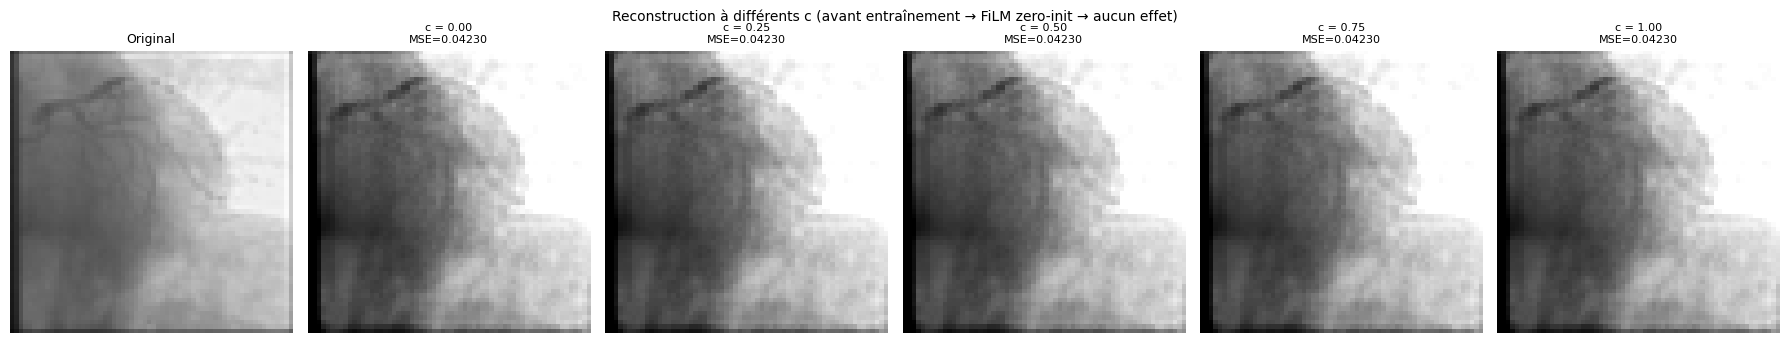

→ Les MSE sont identiques : les FiLM heads sont zero-init (identité).


In [11]:
cvae.eval()
x_single = imgs_demo[:1].to(DEVICE)  # une seule image

c_values = [0.0, 0.25, 0.5, 0.75, 1.0]
recs = []
with torch.no_grad():
    for c_val in c_values:
        c_t = torch.tensor([c_val], dtype=torch.float32, device=DEVICE)
        rec, _ = cvae(x_single, c_t, sample_posterior=False)
        recs.append(rec.squeeze().cpu().numpy())

fig, axes = plt.subplots(1, len(c_values) + 1, figsize=(3 * (len(c_values) + 1), 3.5))

orig = x_single.squeeze().cpu().numpy()
axes[0].imshow((orig + 1) / 2, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Original", fontsize=9)
axes[0].axis("off")

for i, (c_val, rec) in enumerate(zip(c_values, recs)):
    axes[i + 1].imshow((rec + 1) / 2, cmap="gray", vmin=0, vmax=1)
    mse = float(np.mean((orig - rec) ** 2))
    axes[i + 1].set_title(f"c = {c_val:.2f}\nMSE={mse:.5f}", fontsize=8)
    axes[i + 1].axis("off")

fig.suptitle("Reconstruction à différents c (avant entraînement → FiLM zero-init → aucun effet)",
             fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_conditioning_before_training.png", dpi=120, bbox_inches="tight")
plt.show()
print("→ Les MSE sont identiques : les FiLM heads sont zero-init (identité).")

## 8. Entraînement — Phase 1 : Warm-up FiLM

**Stratégie en deux phases :**

| Phase | Paramètres entraînés | Steps | LR | Objectif |
|---|---|---|---|---|
| **1 — Warm-up** | FiLM seul (2.7%) | 2 500 | 4.5e-6 | Initialiser le conditionnement |
| **2 — Fine-tuning** | Tout le réseau | 5 000 | 1e-6 | Ajuster le VAE complet |

Validation toutes les 250 steps avec early stopping (patience = 10).

In [12]:
def elbo_loss(x, rec, posterior, kl_weight=KL_WEIGHT):
    rec_loss = F.mse_loss(rec, x)
    kl_loss  = posterior.kl().mean()
    loss     = rec_loss + kl_weight * kl_loss
    return loss, {"rec": rec_loss.item(), "kl": kl_loss.item(), "total": loss.item()}


@torch.no_grad()
def validate(model, val_loader, device):
    """Calcule la loss moyenne sur le set de validation."""
    model.eval()
    total_loss, total_rec, total_kl, n = 0, 0, 0, 0
    for x_batch, c_batch in val_loader:
        x_batch, c_batch = x_batch.to(device), c_batch.to(device)
        rec_batch, post_batch = model(x_batch, c_batch, sample_posterior=False)
        _, logs = elbo_loss(x_batch, rec_batch, post_batch)
        bs = x_batch.size(0)
        total_loss += logs["total"] * bs
        total_rec  += logs["rec"] * bs
        total_kl   += logs["kl"] * bs
        n += bs
    model.train()
    return {"total": total_loss / n, "rec": total_rec / n, "kl": total_kl / n}


print("Loss ELBO et fonction de validation définies.")

Loss ELBO et fonction de validation définies.


In [13]:
# ──────────────────────────────────────────────────────────────
# Phase 1 : Warm-up — seuls les paramètres FiLM sont entraînés
# (les poids de base du MedVAE sont gelés).
# ──────────────────────────────────────────────────────────────

# 1) Geler tous les poids de base
for p in cvae.parameters():
    p.requires_grad_(False)

# 2) Dégeler uniquement les paramètres FiLM
for p in cvae.film.parameters():
    p.requires_grad_(True)

trainable = [p for p in cvae.parameters() if p.requires_grad]
n_trainable = sum(p.numel() for p in trainable)
n_total     = sum(p.numel() for p in cvae.parameters())
print(f"Paramètres entraînables : {n_trainable:,} / {n_total:,} ({100*n_trainable/n_total:.3f}%)")

optimizer = torch.optim.AdamW(trainable, lr=WARMUP_LR, weight_decay=0.0)
cvae.train()

history_warmup = {"total": [], "rec": [], "kl": [], "val_total": [], "val_rec": []}
best_val_loss  = float("inf")
best_state     = None
patience_ctr   = 0
step = 0
loader_iter = iter(loader)

pbar = tqdm(total=N_WARMUP_STEPS, desc="Phase 1 — Warm-up FiLM")

while step < N_WARMUP_STEPS:
    try:
        x_batch, c_batch = next(loader_iter)
    except StopIteration:
        loader_iter = iter(loader)
        x_batch, c_batch = next(loader_iter)

    x_batch = x_batch.to(DEVICE)
    c_batch = c_batch.to(DEVICE)

    rec_batch, post_batch = cvae(x_batch, c_batch, sample_posterior=True)
    loss, logs = elbo_loss(x_batch, rec_batch, post_batch)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(trainable, 1.0)
    optimizer.step()

    for k in ["total", "rec", "kl"]:
        history_warmup[k].append(logs[k])

    step += 1

    # --- Validation périodique ---
    if step % VAL_EVERY == 0 or step == N_WARMUP_STEPS:
        val_logs = validate(cvae, loader_val, DEVICE)
        history_warmup["val_total"].append(val_logs["total"])
        history_warmup["val_rec"].append(val_logs["rec"])
        cvae.train()

        improved = val_logs["total"] < best_val_loss
        if improved:
            best_val_loss = val_logs["total"]
            best_state = {k: v.cpu().clone() for k, v in cvae.state_dict().items()}
            patience_ctr = 0
            marker = " ★"
        else:
            patience_ctr += 1
            marker = ""

        pbar.set_postfix({
            "train": f"{logs['total']:.5f}",
            "val": f"{val_logs['total']:.5f}{marker}",
            "pat": f"{patience_ctr}/{PATIENCE}",
        })

        if patience_ctr >= PATIENCE:
            print(f"\n⚠ Early stopping à step {step} (patience épuisée)")
            break
    else:
        pbar.set_postfix({"loss": f"{logs['total']:.5f}", "rec": f"{logs['rec']:.5f}"})

    pbar.update(1)

pbar.close()

# Restaurer le meilleur modèle
if best_state is not None:
    cvae.load_state_dict(best_state)
    print(f"Meilleur modèle restauré (val_loss = {best_val_loss:.6f})")

print(f"Phase 1 terminée — {step} steps, best val loss : {best_val_loss:.6f}")

Paramètres entraînables : 1,700,992 / 57,059,837 (2.981%)


Phase 1 — Warm-up FiLM: 100%|██████████| 2500/2500 [04:50<00:00,  8.60it/s, train=0.02142, val=0.01804 ★, pat=0/10]

Meilleur modèle restauré (val_loss = 0.018035)
Phase 1 terminée — 2500 steps, best val loss : 0.018035


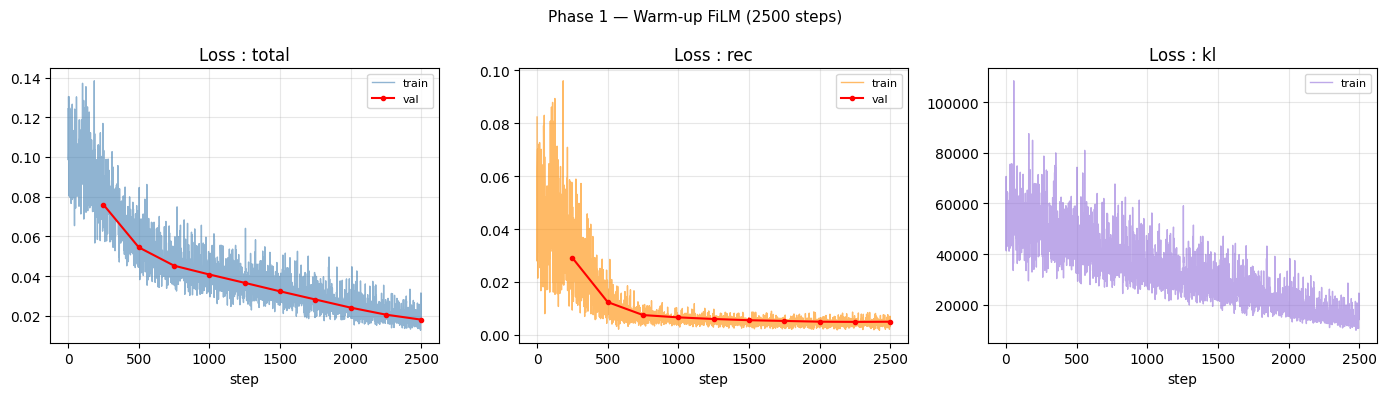

In [14]:
# Courbes de loss — Phase 1 (Warm-up FiLM)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, key, color in zip(axes, ["total", "rec", "kl"],
                           ["steelblue", "darkorange", "mediumpurple"]):
    ax.plot(history_warmup[key], color=color, lw=1, alpha=0.6, label="train")
    # Validation (échantillonnée tous les VAL_EVERY steps)
    if f"val_{key}" in history_warmup and history_warmup.get(f"val_{key}"):
        val_x = list(range(VAL_EVERY, VAL_EVERY * len(history_warmup[f"val_{key}"]) + 1, VAL_EVERY))
        ax.plot(val_x, history_warmup[f"val_{key}"], "o-", color="red", ms=3, lw=1.5, label="val")
    ax.set_title(f"Loss : {key}")
    ax.set_xlabel("step")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Phase 1 — Warm-up FiLM ({len(history_warmup['total'])} steps)", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_warmup_curves.png", dpi=100, bbox_inches="tight")
plt.show()

## 9. Visualisation après entraînement : le score c commence à avoir un effet

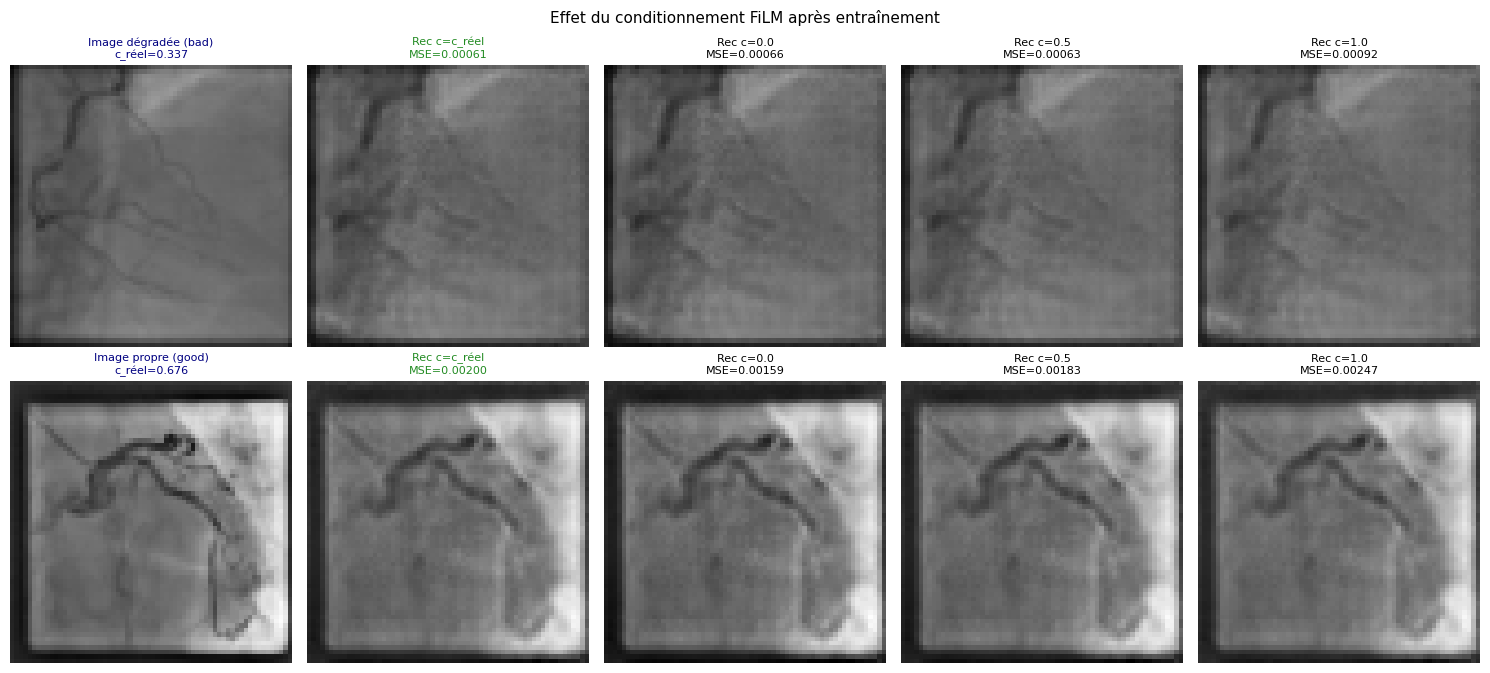

In [15]:
cvae.eval()

# Prendre une image "bad" et une image "good"
df_bad  = df_labels[df_labels["quality_label"] == "bad"].head(1)
df_good = df_labels[df_labels["quality_label"] == "good"].head(1)

def load_and_prepare(row, img_size=DDCONFIG["resolution"]):
    img = Image.open(row["path"].values[0]).convert("L")
    img = img.resize((img_size, img_size), Image.Resampling.BILINEAR)
    t   = torch.from_numpy(np.asarray(img, np.float32) / 255.0).unsqueeze(0).unsqueeze(0)
    return (t * 2.0 - 1.0).to(DEVICE)

imgs_pair  = [load_and_prepare(df_bad),  load_and_prepare(df_good)]
labels_pair= ["Image dégradée (bad)",    "Image propre (good)"]
c_real_pair= [float(df_bad["quality_score"].values[0]),
              float(df_good["quality_score"].values[0])]

c_test_vals = [0.0, 0.5, 1.0]

fig, axes = plt.subplots(2, len(c_test_vals) + 2, figsize=(3 * (len(c_test_vals) + 2), 7))

for row, (x_img, lbl, c_real) in enumerate(zip(imgs_pair, labels_pair, c_real_pair)):
    # Colonne 0 : original
    orig_np = ((x_img.squeeze().cpu().numpy() + 1) / 2).clip(0, 1)
    axes[row, 0].imshow(orig_np, cmap="gray", vmin=0, vmax=1)
    axes[row, 0].set_title(f"{lbl}\nc_réel={c_real:.3f}", fontsize=8, color="navy")
    axes[row, 0].axis("off")

    # Colonne 1 : reconstruction avec c réel
    with torch.no_grad():
        c_t   = torch.tensor([c_real], device=DEVICE)
        rec_r, _ = cvae(x_img, c_t, sample_posterior=False)
    rec_np = ((rec_r.squeeze().cpu().numpy() + 1) / 2).clip(0, 1)
    axes[row, 1].imshow(rec_np, cmap="gray", vmin=0, vmax=1)
    axes[row, 1].set_title(f"Rec c=c_réel\nMSE={np.mean((orig_np - rec_np)**2):.5f}",
                            fontsize=8, color="forestgreen")
    axes[row, 1].axis("off")

    # Colonnes 2+ : c imposé
    for col, c_val in enumerate(c_test_vals):
        with torch.no_grad():
            c_t2  = torch.tensor([c_val], device=DEVICE)
            rec_t, _ = cvae(x_img, c_t2, sample_posterior=False)
        rec_np2 = ((rec_t.squeeze().cpu().numpy() + 1) / 2).clip(0, 1)
        axes[row, col + 2].imshow(rec_np2, cmap="gray", vmin=0, vmax=1)
        axes[row, col + 2].set_title(
            f"Rec c={c_val:.1f}\nMSE={np.mean((orig_np - rec_np2)**2):.5f}", fontsize=8
        )
        axes[row, col + 2].axis("off")

fig.suptitle("Effet du conditionnement FiLM après entraînement", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_conditioning_after_training.png", dpi=120, bbox_inches="tight")
plt.show()

## 10. Entraînement — Phase 2 : Fine-tuning global

Tous les poids du réseau (base VAE + FiLM) sont maintenant dégelés.  
Le LR est réduit pour ne pas détruire les représentations apprises pendant le pré-entraînement.

In [16]:
# ──────────────────────────────────────────────────────────────
# Phase 2 : Fine-tuning global — tous les poids sont entraînés
# ──────────────────────────────────────────────────────────────

# Dégeler tout le réseau
for p in cvae.parameters():
    p.requires_grad_(True)

all_params  = list(cvae.parameters())
n_trainable = sum(p.numel() for p in all_params)
print(f"Paramètres entraînables : {n_trainable:,} (100%)")

optimizer_ft = torch.optim.AdamW(all_params, lr=FINETUNE_LR, weight_decay=1e-4)
# Scheduler cosine pour décroître le LR progressivement
scheduler_ft = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ft, T_max=N_FINETUNE_STEPS, eta_min=1e-7
)
cvae.train()

history_ft = {"total": [], "rec": [], "kl": [], "val_total": [], "val_rec": []}
best_val_loss_ft = float("inf")
best_state_ft    = None
patience_ctr_ft  = 0
step_ft = 0
loader_iter_ft = iter(loader)

pbar_ft = tqdm(total=N_FINETUNE_STEPS, desc="Phase 2 — Fine-tuning global")

while step_ft < N_FINETUNE_STEPS:
    try:
        x_batch, c_batch = next(loader_iter_ft)
    except StopIteration:
        loader_iter_ft = iter(loader)
        x_batch, c_batch = next(loader_iter_ft)

    x_batch = x_batch.to(DEVICE)
    c_batch = c_batch.to(DEVICE)

    rec_batch, post_batch = cvae(x_batch, c_batch, sample_posterior=True)
    loss, logs = elbo_loss(x_batch, rec_batch, post_batch)

    optimizer_ft.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(all_params, 1.0)
    optimizer_ft.step()
    scheduler_ft.step()

    for k in ["total", "rec", "kl"]:
        history_ft[k].append(logs[k])

    step_ft += 1

    # --- Validation périodique ---
    if step_ft % VAL_EVERY == 0 or step_ft == N_FINETUNE_STEPS:
        val_logs = validate(cvae, loader_val, DEVICE)
        history_ft["val_total"].append(val_logs["total"])
        history_ft["val_rec"].append(val_logs["rec"])
        cvae.train()

        improved = val_logs["total"] < best_val_loss_ft
        if improved:
            best_val_loss_ft = val_logs["total"]
            best_state_ft = {k: v.cpu().clone() for k, v in cvae.state_dict().items()}
            patience_ctr_ft = 0
            marker = " ★"
        else:
            patience_ctr_ft += 1
            marker = ""

        lr_now = scheduler_ft.get_last_lr()[0]
        pbar_ft.set_postfix({
            "train": f"{logs['total']:.5f}",
            "val": f"{val_logs['total']:.5f}{marker}",
            "lr": f"{lr_now:.1e}",
            "pat": f"{patience_ctr_ft}/{PATIENCE}",
        })

        if patience_ctr_ft >= PATIENCE:
            print(f"\n⚠ Early stopping à step {step_ft} (patience épuisée)")
            break
    else:
        pbar_ft.set_postfix({"loss": f"{logs['total']:.5f}", "rec": f"{logs['rec']:.5f}"})

    pbar_ft.update(1)

pbar_ft.close()

# Restaurer le meilleur modèle
if best_state_ft is not None:
    cvae.load_state_dict(best_state_ft)
    print(f"Meilleur modèle restauré (val_loss = {best_val_loss_ft:.6f})")

print(f"Phase 2 terminée — {step_ft} steps, best val loss : {best_val_loss_ft:.6f}")
print(f"Total entraînement : {len(history_warmup['total']) + step_ft} steps")

Paramètres entraînables : 57,059,837 (100%)


Phase 2 — Fine-tuning global:   0%|          | 0/5000 [00:00<?, ?it/s]

Phase 2 — Fine-tuning global: 100%|██████████| 5000/5000 [11:19<00:00,  7.36it/s, train=0.00933, val=0.00738 ★, lr=1.0e-07, pat=0/10]  

Meilleur modèle restauré (val_loss = 0.007379)
Phase 2 terminée — 5000 steps, best val loss : 0.007379
Total entraînement : 7500 steps


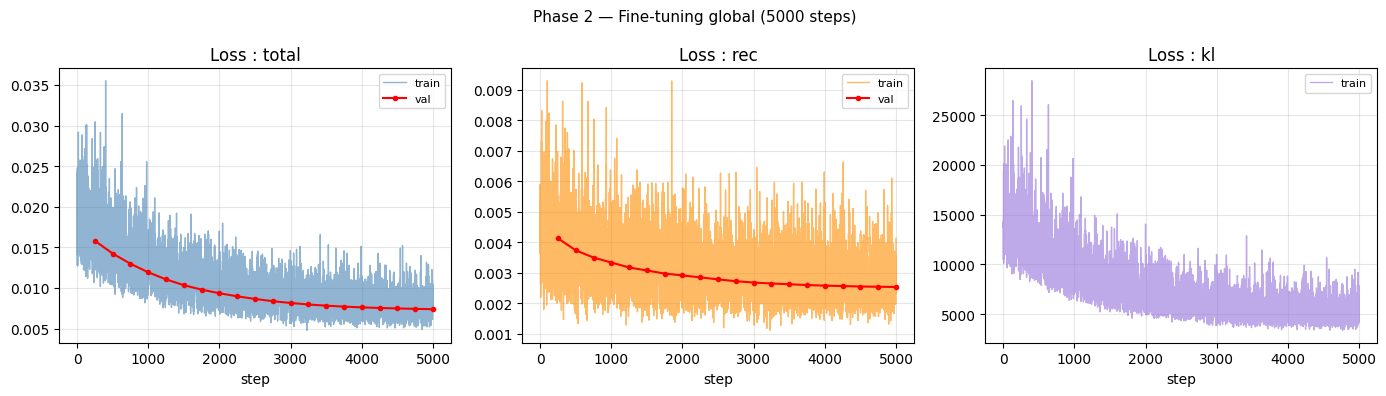

In [17]:
# Courbes de loss — Phase 2 (Fine-tuning global)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, key, color in zip(axes, ["total", "rec", "kl"],
                           ["steelblue", "darkorange", "mediumpurple"]):
    ax.plot(history_ft[key], color=color, lw=1, alpha=0.6, label="train")
    if f"val_{key}" in history_ft and history_ft.get(f"val_{key}"):
        val_x = list(range(VAL_EVERY, VAL_EVERY * len(history_ft[f"val_{key}"]) + 1, VAL_EVERY))
        ax.plot(val_x, history_ft[f"val_{key}"], "o-", color="red", ms=3, lw=1.5, label="val")
    ax.set_title(f"Loss : {key}")
    ax.set_xlabel("step")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Phase 2 — Fine-tuning global ({len(history_ft['total'])} steps)", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_finetune_curves.png", dpi=100, bbox_inches="tight")
plt.show()

## 10. Sauvegarde du checkpoint

Le checkpoint contient le modèle conditionné ET la config nécessaire pour le reconstruire dans le Notebook 5.

In [18]:
total_steps = len(history_warmup["total"]) + len(history_ft["total"])

checkpoint = {
    "model_state_dict":  cvae.state_dict(),
    "ddconfig":          DDCONFIG,
    "embed_dim":         EMBED_DIM,
    "approach":          APPROACH,
    "training_steps":    total_steps,
    "warmup_steps":      len(history_warmup["total"]),
    "finetune_steps":    len(history_ft["total"]),
    "best_val_loss":     best_val_loss_ft,
    "history_warmup":    history_warmup,
    "history_finetune":  history_ft,
    "labels_csv":        str(LABELS_CSV),
    "param_count":       cvae.param_count(),
}

torch.save(checkpoint, CVAE_CKPT_OUT)
print(f"Checkpoint sauvegardé → {CVAE_CKPT_OUT}")
print(f"Approche         : {APPROACH}")
print(f"Taille fichier   : {CVAE_CKPT_OUT.stat().st_size / 1e6:.1f} MB")
print(f"Steps totaux     : {total_steps}")
print(f"Best val loss    : {best_val_loss_ft:.6f}")

Checkpoint sauvegardé → outputs_theophile/04_MedVAE_Architecture_Mod/approach_A/quality_aware_vae.pt
Approche         : A
Taille fichier   : 228.5 MB
Steps totaux     : 7500
Best val loss    : 0.007379


In [19]:
# Vérification du rechargement
def load_quality_aware_vae(ckpt_path: Path) -> QualityAwareAutoencoderKL:
    ckpt    = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    base_ae = AutoencoderKL2D(
        ddconfig         = ckpt["ddconfig"],
        embed_dim        = ckpt["embed_dim"],
        apply_channel_ds = True,
    )
    model = QualityAwareAutoencoderKL(base_ae)
    model.load_state_dict(ckpt["model_state_dict"])
    return model

cvae_reloaded = load_quality_aware_vae(CVAE_CKPT_OUT)
print(f"Rechargement OK : {cvae_reloaded.param_count()}")
print(f"Training steps  : {checkpoint['training_steps']}")
print(f"Best val loss   : {checkpoint['best_val_loss']:.6f}")

Rechargement OK : {'total': 57059837, 'film_params': 1700992, 'ratio_%': 2.981}
Training steps  : 7500
Best val loss   : 0.007379


## Résumé du Notebook 4

| Composant | Modification | Détail |
|---|---|---|
| **FiLM MLP** | `nn.Linear(1 → 128 → 128)` | Embedding partagé du score $c$ |
| **FiLM heads** | 19 × `nn.Linear(128 → 2·ch)` | $(\gamma_i, \beta_i)$ par ResnetBlock |
| **Modulation** | $h \leftarrow (1 + \gamma) \cdot h + \beta$ | Après chaque ResnetBlock (19 blocs) |
| Poids existants | **Inchangés** | Aucune modification du modèle de base |
| Zero-init | Toutes les heads FiLM | Pas d'effet au démarrage → stabilité |
| `QualityAwareArcadeDataset` | Retourne `(img, c)` | c lu depuis `labels_quality.csv` |
| Paramètres FiLM | **~2.7%** du total | Expressif mais léger |

### Entraînement en deux phases

| Phase | Paramètres | Steps | LR | Scheduler |
|---|---|---|---|---|
| **1 — Warm-up** | FiLM seul (2.7%) | 2 500 | 4.5e-6 | — |
| **2 — Fine-tuning** | Tout le réseau (100%) | 5 000 | 1e-6 | Cosine → 1e-7 |

- Validation toutes les 250 steps + early stopping (patience = 10)
- Meilleur modèle sélectionné sur la val loss

### FiLM vs Concaténation de canal

| | Concaténation | FiLM |
|---|---|---|
| Point d'injection | Entrée seule | Chaque couche (19 blocs) |
| Modification du modèle | Patch `conv_in` | Aucune (hooks) |
| Type de modulation | Canal constant additionnel | Scale + shift appris |
| Expressivité | Faible (1 signal spatial) | Élevée (modulation multi-échelle) |
| Référence | — | Perez et al., AAAI 2018 |

**Prochain notebook :** `05_Evaluation_of_Robustness.ipynb` —
Comparer MedVAE baseline vs Quality-Aware sur les images dégradées.